In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from glob import glob
import pandas as pd
import os


In [4]:
ds = xr.load_dataset('../data/model/ocean_dunex_rst.nc').isel(ocean_time=-1)
ds

/Users/mleclair/.pyenv/versions/3.12.1/lib/python3.12/site-packages/xarray/coding/times.py:995: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/mleclair/.pyenv/versions/3.12.1/lib/python3.12/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/Users/mleclair/.pyenv/versions/3.12.1/lib/python3.12/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


<xarray.Dataset> Size: 1GB
Dimensions:          (tracer: 1, s_rho: 16, s_w: 17, eta_rho: 1001,
                      xi_rho: 901, eta_u: 1001, xi_u: 900, eta_v: 1000,
                      xi_v: 901, eta_psi: 1000, xi_psi: 900)
Coordinates:
  * s_rho            (s_rho) float64 128B -0.9688 -0.9062 ... -0.09375 -0.03125
  * s_w              (s_w) float64 136B -1.0 -0.9375 -0.875 ... -0.0625 0.0
    x_rho            (eta_rho, xi_rho) float64 7MB 50.0 51.0 ... 949.0 950.0
    y_rho            (eta_rho, xi_rho) float64 7MB -1.2e+03 -1.2e+03 ... 1.8e+03
    x_u              (eta_u, xi_u) float64 7MB 50.5 51.5 52.5 ... 948.5 949.5
    y_u              (eta_u, xi_u) float64 7MB -1.2e+03 -1.2e+03 ... 1.8e+03
    x_v              (eta_v, xi_v) float64 7MB 50.0 51.0 52.0 ... 949.0 950.0
    y_v              (eta_v, xi_v) float64 7MB -1.198e+03 ... 1.798e+03
    x_psi            (eta_psi, xi_psi) float64 7MB 50.5 51.5 ... 948.5 949.5
    y_psi            (eta_psi, xi_psi) float64 7MB -1.198e+03 ... 1.798e+03
    ocean_time       object 8B 0001-01-01 02:00:00
Dimensions without coordinates: tracer, eta_rho, xi_rho, eta_u, xi_u, eta_v,
                                xi_v, eta_psi, xi_psi
Data variables: (12/103)
    ntimes           int32 4B 14400
    ndtfast          int32 4B 20
    dt               float64 8B 0.5
    dtfast           float64 8B 0.025
    dstart           object 8B 0001-01-01 00:00:00
    nHIS             int32 4B 600
    ...               ...
    ubar_stokes      (eta_u, xi_u) float64 7MB nan nan nan ... -0.01033 -0.01033
    vbar_stokes      (eta_v, xi_v) float64 7MB nan nan ... -0.003493 -0.003493
    u_stokes         (s_rho, eta_u, xi_u) float64 115MB nan nan ... -0.03858
    v_stokes         (s_rho, eta_v, xi_v) float64 115MB nan nan ... -0.01134
    omega_stokes     (s_w, eta_rho, xi_rho) float64 123MB 0.0 0.0 ... 0.0 0.0
    w_stokes         (s_w, eta_rho, xi_rho) float64 123MB 0.0 0.0 ... 0.0 0.0
Attributes: (12/25)
    file:              ./output/ocean_dunex_rst.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS restart file
    title:             DUNEX
    var_info:          /gscratch/derakhti/shared/COAWST/ROMS/External/varinfo...
    ...                ...
    compiler_command:  /sw/ompi/4.1.0/bin/mpif90
    compiler_flags:    -frepack-arrays -O3 -ffast-math -O3 -ftree-vectorize -...
    tiling:            005x005
    history:           ROMS/TOMS, Version 3.8, Thursday - May 9, 2024 -  5:06...
    ana_file:          ROMS/Functionals/ana_btflux.h, ROMS/Functionals/ana_in...
    CPP_options:       DUNEX, ANA_BSFLUX, ANA_BTFLUX, ANA_INITIAL, ANA_SEDIME...

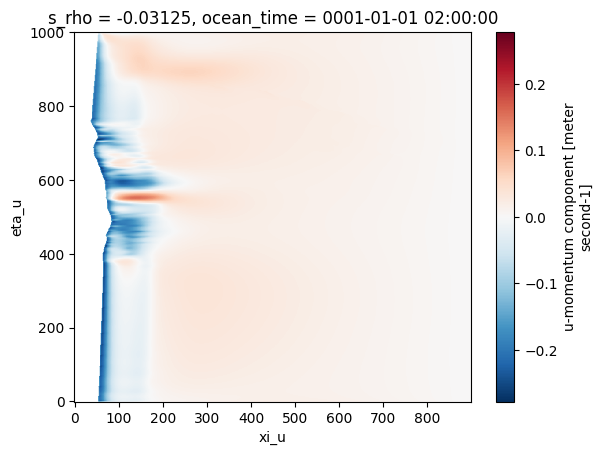

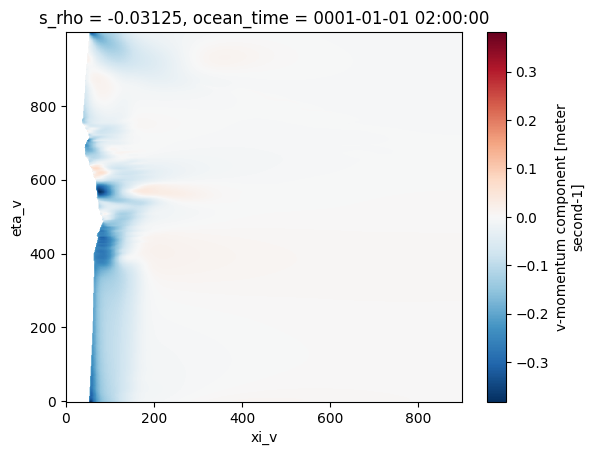

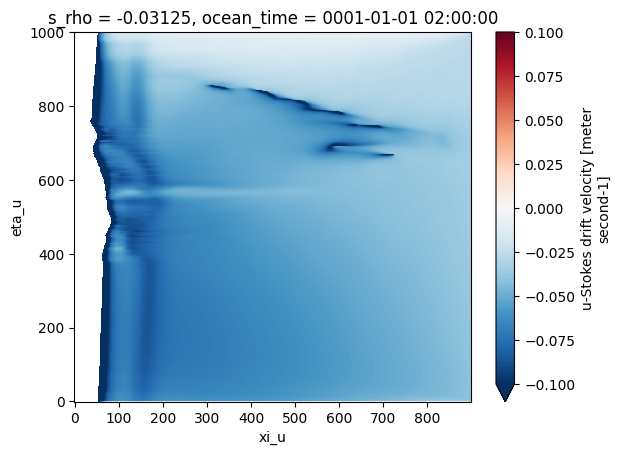

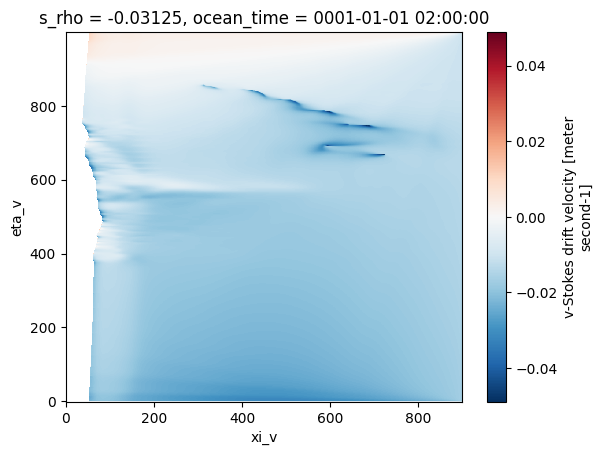

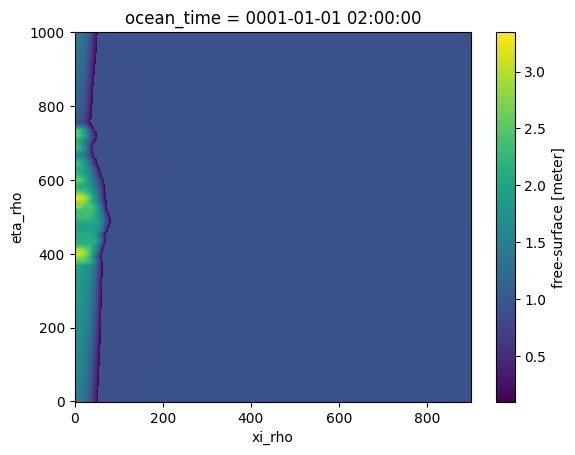

In [24]:
ds.u.isel(s_rho=-1).plot()
plt.figure()
ds.v.isel(s_rho=-1).plot()
plt.figure()
ds.u_stokes.isel(s_rho=-1).plot(cmap='RdBu_r', vmin=-0.1, vmax=0.1)
plt.figure()
ds.v_stokes.isel(s_rho=-1).plot()
plt.figure()
ds.zeta.plot()